# Proyecto 1: La erosión de la riqueza (Inflación y Poder Adquisitivo en Perú)


## 1. Problema 📊
¿Cuanto poder de compra hemos perdido los peruanos en los ultimos años?

>La inflación es el impuesto más severo sobre la riqueza.  En un escenario ideal, el Banco Central de Reserva del Perú (BCRP) mantiene estrictamente la meta de inflación entre el 1% y el 3%.  Sin embargo, los recientes choques sistémicos globales (como las interrupciones logísticas posteriores a la COVID y los conflictos geopolíticos) han fracturado gravemente el poder adquisitivo del sol peruano.  Este proyecto cuantifica matemáticamente la velocidad de esta pérdida desde una línea de base previa a la crisis (2018) utilizando un deflactor indexado.

## 2. Datos 📊
Para este análisis, **no utilizaremos hojas de exels.**  Nos conectaremos directamente a la **API Oficial del BCRP (Banco Central de Reserva del Perú)**.

- **Serie PN01273PM:** Inflación interanual (IPC Lima Metropolitana).
- **Serie PN38705PM:** Índice de Precios al Consumidor (Base Dic 2021 = 100).

## 3. Código y Procesamiento 💻
A continuación, extraemos y limpiamos los datos mediante Python.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
import json
import ssl

# Ignorar chequeos SSL para la API pública del BCRP
ctx = ssl.create_default_context()
ctx.check_hostname = False
ctx.verify_mode = ssl.CERT_NONE

In [2]:
def extraer_bcrp(serie: str, inicio: str, fin: str) -> pd.DataFrame:
    url = f"https://estadisticas.bcrp.gob.pe/estadisticas/series/api/{serie}/json/{inicio}/{fin}"
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})

    with urllib.request.urlopen(req, context=ctx) as response:
        data = json.loads(response.read().decode())

    registros = []
    for p in data["periods"]:
        # Convertir 'Ene.2018' a fecha YYYY-MM-DD
        mes_es, anio = p["name"].split(".")
        meses = {"Ene": "01", "Feb": "02", "Mar": "03", "Abr": "04",
                 "May": "05", "Jun": "06", "Jul": "07", "Ago": "08",
                 "Sep": "09", "Oct": "10", "Nov": "11", "Dic": "12"}
        fecha = f"{anio}-{meses[mes_es]}-01"
        registros.append({"fecha": fecha, "valor": float(p["values"][0])})

    df = pd.DataFrame(registros)
    df["fecha"] = pd.to_datetime(df["fecha"])
    return df

In [3]:
# 1. Extraer
df_inflacion = extraer_bcrp("PN01273PM", "2018-01", "2024-12").rename(columns={"valor": "inflacion_anual"})
df_ipc = extraer_bcrp("PN38705PM", "2018-01", "2024-12").rename(columns={"valor": "indice_precios"})

# 2. Unir y Limpiar
clean = pd.merge(df_inflacion, df_ipc, on="fecha")

# 3. Métrica de Poder Adquisitivo (Economics)
ipc_base = clean["indice_precios"].iloc[0]
clean["poder_adquisitivo_base100"] = 100 * (ipc_base / clean["indice_precios"])

clean.tail()

,fecha,inflacion_anual,indice_precios,poder_adquisitivo_base100
79,2024-08-01,2.034097,114.322048,77.495680
80,2024-09-01,1.775011,114.050464,77.680218
81,2024-10-01,2.009180,113.944279,77.752608
82,2024-11-01,2.271991,114.051561,77.679470
83,2024-12-01,1.966303,114.172077,77.597475


## 4. Visualización 📈
Gráficos con alto nivel estético listos para presentaciones directivas.

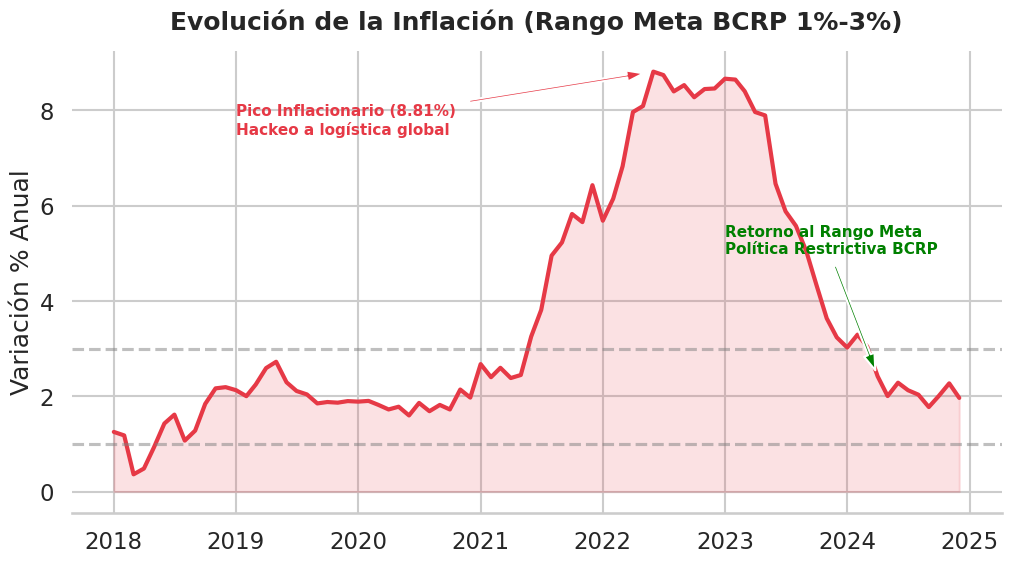

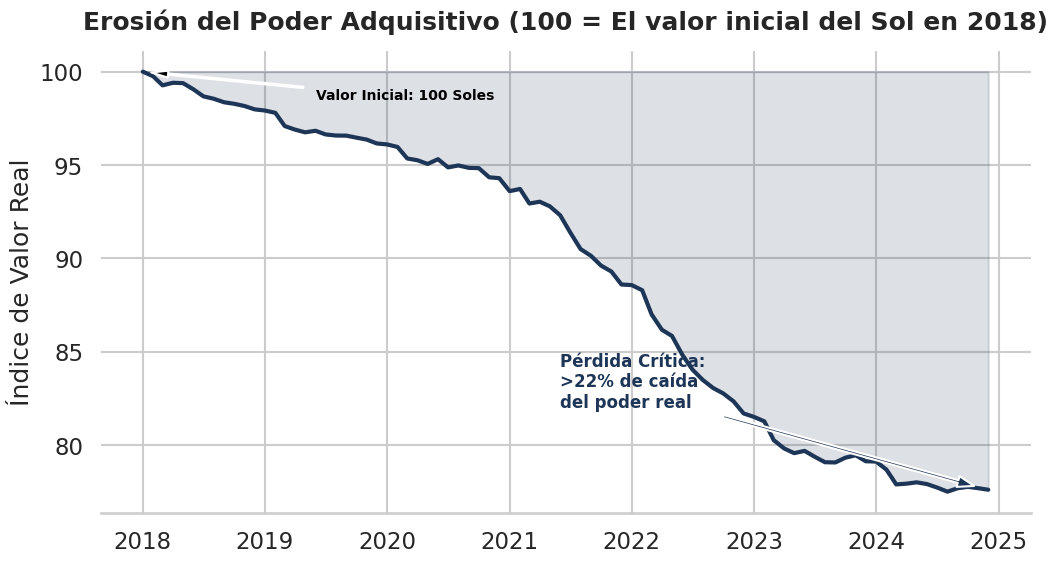

In [4]:
sns.set_theme(style="whitegrid", context="talk")
color_inf = "#E63946"
import datetime

# --- GRÁFICO 1 ---
fig1, ax1 = plt.subplots(figsize=(12, 6))
sns.lineplot(data=clean, x="fecha", y="inflacion_anual", ax=ax1, color=color_inf, linewidth=3)
ax1.fill_between(clean["fecha"], clean["inflacion_anual"], color=color_inf, alpha=0.15)
ax1.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
ax1.axhline(3.0, color="gray", linestyle="--", alpha=0.5)

# Anotaciones PRO
ax1.annotate('Pico Inflacionario (8.81%)\nHackeo a logística global',
             xy=(pd.to_datetime("2022-06-01"), 8.81), xytext=(pd.to_datetime("2019-01-01"), 7.5),
             arrowprops=dict(facecolor='#E63946', shrink=0.05, width=2, headwidth=8),
             fontsize=11, fontweight='bold', color='#E63946')

ax1.annotate('Retorno al Rango Meta\nPolítica Restrictiva BCRP',
             xy=(pd.to_datetime("2024-04-01"), 2.42), xytext=(pd.to_datetime("2023-01-01"), 5),
             arrowprops=dict(facecolor='green', shrink=0.05, width=2, headwidth=8),
             fontsize=11, fontweight='bold', color='green')

ax1.set_title("Evolución de la Inflación (Rango Meta BCRP 1%-3%)", fontweight="bold", pad=15)
ax1.set_ylabel("Variación % Anual")
ax1.set_xlabel("")
sns.despine(left=True)
plt.show()

# --- GRÁFICO 2 ---
color_poder = "#1D3557"
fig2, ax2 = plt.subplots(figsize=(12, 6))
sns.lineplot(data=clean, x="fecha", y="poder_adquisitivo_base100", ax=ax2, color=color_poder, linewidth=3)
ax2.fill_between(clean["fecha"], clean["poder_adquisitivo_base100"], 100, color=color_poder, alpha=0.15)

# Anotaciones PRO
ax2.annotate('Valor Inicial: 100 Soles',
             xy=(pd.to_datetime("2018-01-01"), 100), xytext=(pd.to_datetime("2019-06-01"), 98.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
             fontsize=10, fontweight='bold', color='black')

ax2.annotate('Pérdida Crítica:\n>22% de caída\ndel poder real',
             xy=(pd.to_datetime("2024-12-01"), 77.59), xytext=(pd.to_datetime("2021-06-01"), 82),
             arrowprops=dict(facecolor='#1D3557', shrink=0.05, width=2, headwidth=8),
             fontsize=12, fontweight='bold', color='#1D3557')

ax2.set_title("Erosión del Poder Adquisitivo (100 = El valor inicial del Sol en 2018)", fontweight="bold", pad=15)
ax2.set_ylabel("Índice de Valor Real")
ax2.set_xlabel("")
sns.despine(left=True)
plt.show()


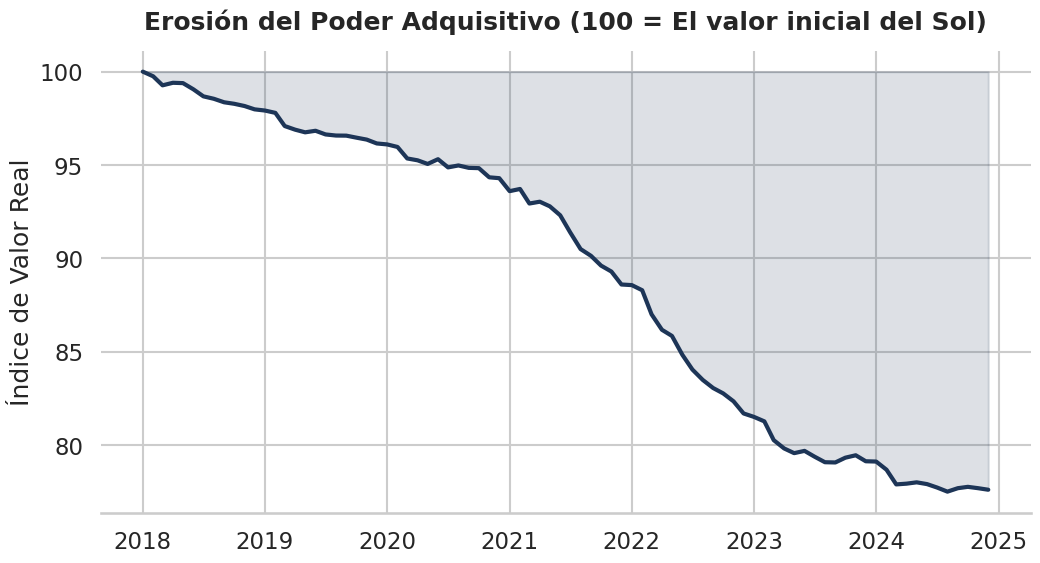

In [5]:
color_poder = "#1D3557"

fig2, ax2 = plt.subplots(figsize=(12, 6))
sns.lineplot(data=clean, x="fecha", y="poder_adquisitivo_base100", ax=ax2, color=color_poder, linewidth=3)
ax2.fill_between(clean["fecha"], clean["poder_adquisitivo_base100"], 100, color=color_poder, alpha=0.15)
ax2.set_title("Erosión del Poder Adquisitivo (100 = El valor inicial del Sol)", fontweight="bold", pad=15)
ax2.set_ylabel("Índice de Valor Real")
ax2.set_xlabel("")
sns.despine(left=True)
plt.show()

**Análisis Estructural (2018 - 2024):**

Como se observa en el gráfico, la inflación en Perú superó el rango objetivo del BCRP (1%–3%) entre 2021 y 2023, alcanzando un pico de casi el 8,8% en junio de 2022.  Este comportamiento coinciden segun lo investigado con un período marcado por eventos globales significativos: la pandemia de COVID-19 en 2020, las interrupciones logísticas en 2021 (como problemas en puertos y transporte internacional) y el aumento de las tensiones geopolíticas en 2022, como la guerra entre Rusia y Ucrania.  Estos factores impactaron los precios internacionales de la energía, los alimentos y el transporte, contribuyendo al aumento de la inflación.  Posteriormente, alrededor de mediados de 2024, la inflación volvió a niveles cercanos al rango objetivo, en parte debido a medidas tomadas por el BCRP, como el aumento de las tasas de interés.

## 6. Conclusión y Hallazgos 📝

>*Entonces podemos ver un cambio claro en nuestro Perú, el poder adquisitivo ha disminuido.  Si tomamos un ejemplo sencillo, una persona que antes podía hacer ciertas compras con S/100 ahora necesita aproximadamente S/125 para comprar las mismas cosas, o visto de otra manera, esos mismos S/100 ahora equivalen a unos S/75 en términos reales, lo que representa una pérdida de casi el 25% en poder adquisitivo.*
*Este resultado refleja que las personas pueden comprar menos con la misma cantidad de dinero, lo que afecta directamente su bienestar económico.  La disminución del poder adquisitivo coincide con un período marcado por eventos globales significativos, como la pandemia de COVID-19, las interrupciones logísticas y los conflictos geopolíticos que se han desarrollado en los últimos años.  Estos eventos no afectaron a una sola economía, sino a todo el mercado global, impactando los precios de la energía, los alimentos y el transporte.*
*Sin embargo, más allá de las causas, hay un punto clave: aunque la inflación pueda disminuir con el tiempo, el impacto en el poder adquisitivo no se recupera inmediatamente.  Es decir, el daño ya está hecho a corto plazo.*

>*Además, este efecto no es uniforme.  Las personas con ingresos más bajos son las más afectadas, ya que se podria decir que ellos destinan una mayor proporción de su dinero al consumo básico.  Es decir, la inflación puede entenderse como un "impuesto oculto", ya que reduce silenciosamente el valor del dinero, afectando más intensamente a quienes tienen menos.*

**En general, este análisis muestra que la inflación no es solo un indicador económico, sino un fenómeno con efectos reales en la calidad de vida y la estabilidad económica de la población**